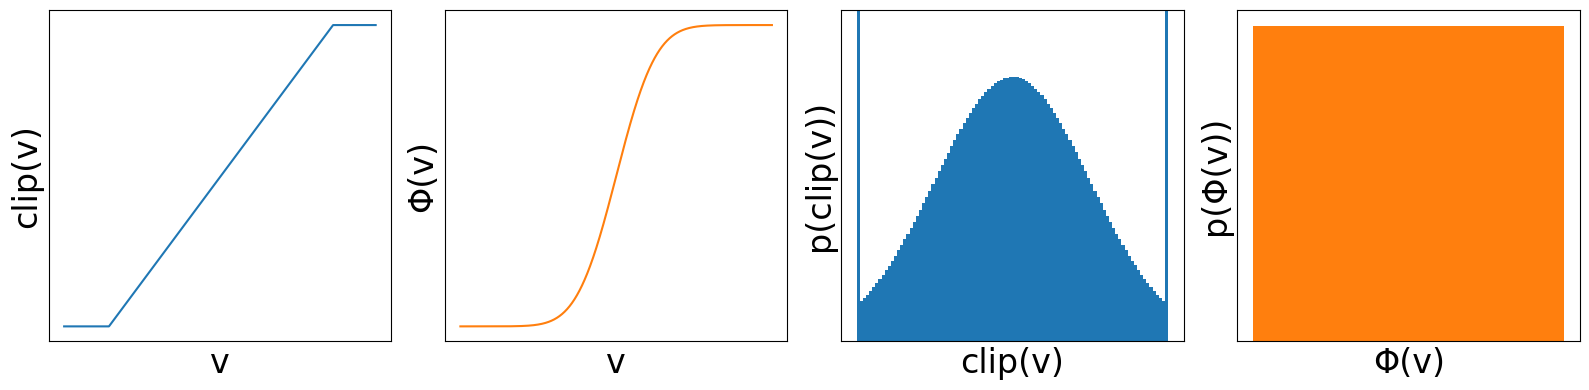

In [7]:
import torch
import matplotlib.pyplot as plt

fontsize = 24

x1 = torch.arange(-0.2, 1.2, 1e-2)
x2 = torch.arange(-5, 5, 1e-2)


fig, axs = plt.subplots(1, 4, figsize=(16, 4))


axs[0].plot(x1, torch.clip(x1, 0, 1), label="clip", color="C0")
axs[0].set_xlabel("v", fontsize=fontsize)
axs[0].set_ylabel("clip(v)", fontsize=fontsize)
axs[1].plot(x2, 0.5 * (torch.erf(x2 / (2 ** 0.5)) + 1), label="Φ", color="C1")
axs[1].set_xlabel("v", fontsize=fontsize)
axs[1].set_ylabel("Φ(v)", fontsize=fontsize)
x = torch.randn((1000_000_000, ))
axs[2].hist(torch.clip(x, -2, 2), density=True, bins=100, label="clip(v)", color="C0")
axs[2].set_xlabel("clip(v)", fontsize=fontsize)
axs[2].set_ylabel("p(clip(v))", fontsize=fontsize)
axs[2].set_ylim(0, 0.5)
axs[3].hist(0.5 * (torch.erf(x / (2 ** 0.5)) + 1), density=True, bins=50, label="Φ(v)", color="C1")
axs[3].set_xlabel("Φ(v)", fontsize=fontsize)
axs[3].set_ylabel("p(Φ(v))", fontsize=fontsize)

for ax in axs:
    ax.set_xticks([], [])
    ax.set_yticks([], [])
    # ax.legend(fontsize=30)

plt.tight_layout()

tensor(0.8198)


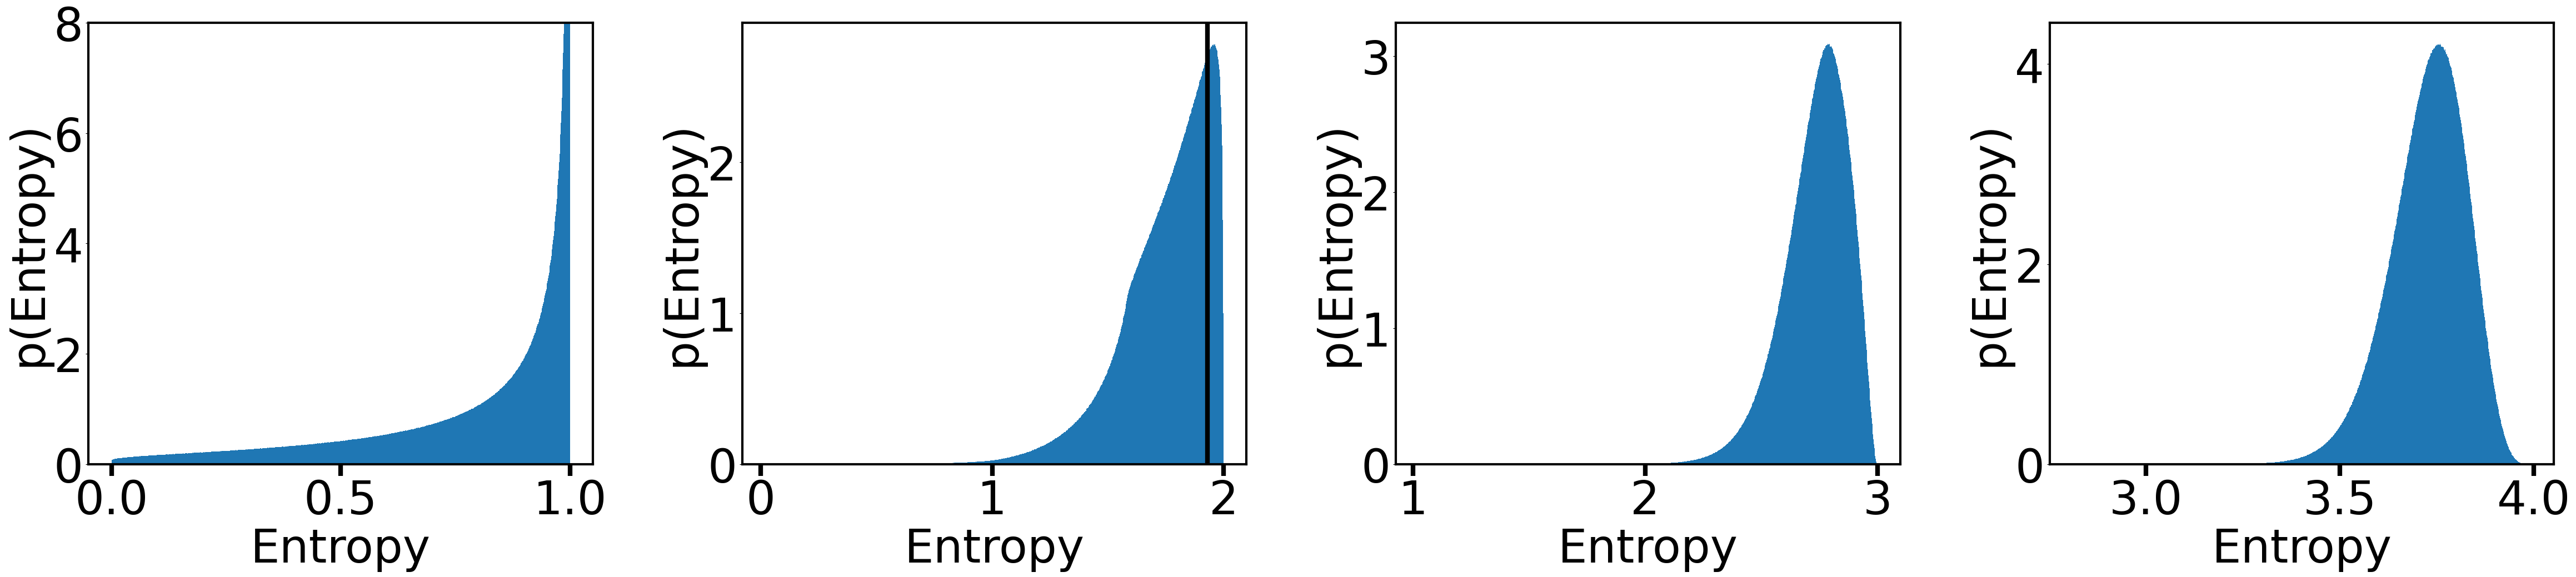

In [18]:
import torch
import matplotlib.pyplot as plt

plt.rcParams["font.size"] = 60
import matplotlib as mpl
plt.rcParams["xtick.major.width"] = 6
plt.rcParams["xtick.major.size"] = 15
mpl.rcParams['axes.linewidth'] = 3

samples, n = 1000_000_00, 4

fig, axs = plt.subplots(1, 4, figsize=(48, 12))
for b in [1, 2, 3, 4]:
    n = 2 ** b
    # Step 1: sample P(q)
    p = torch.rand((samples, n))
    p = p / p.sum(dim=1, keepdim=True)

    # Step 3: compute H(q)
    ent = torch.sum(-p * torch.log2(p), dim=1) 

    # Step 4: plot histogram
    axs[b - 1].hist(ent, bins=1000, density=True)
    axs[b - 1].set_xlabel("Entropy")
    axs[b - 1].set_ylabel("p(Entropy)")
    if b == 1:
        axs[b - 1].set_ylim(0, 8)
    # axs[b - 1].set_title(f"b = {b}")

axs[1].axvline(1.93, color="black", linewidth=6)

p = torch.rand((samples, 4))
p = p / p.sum(dim=1, keepdim=True)

# Step 3: compute H(q)
ent = torch.sum(-p * torch.log2(p), dim=1) 

quest = (ent < 1.93).sum() / ent.numel()
print(quest)

plt.tight_layout()

In [64]:
import torch

normal = torch.distributions.Normal(0, 1)

for p in [4, 3, 2, 1]:
    n = 1 << p
    i = torch.arange(0, n).to(torch.float64)
    bounds = normal.icdf(i / n)
    print(i)
    print(bounds.tolist())

tensor([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
        14., 15.], dtype=torch.float64)
[-inf, -1.5341205443525465, -1.1503493803760083, -0.8871465590188762, -0.6744897501960818, -0.4887764111146696, -0.3186393639643752, -0.1573106846101707, 0.0, 0.1573106846101707, 0.3186393639643752, 0.4887764111146696, 0.6744897501960818, 0.8871465590188762, 1.1503493803760083, 1.5341205443525465]
tensor([0., 1., 2., 3., 4., 5., 6., 7.], dtype=torch.float64)
[-inf, -1.1503493803760083, -0.6744897501960818, -0.3186393639643752, 0.0, 0.3186393639643752, 0.6744897501960818, 1.1503493803760083]
tensor([0., 1., 2., 3.], dtype=torch.float64)
[-inf, -0.6744897501960818, 0.0, 0.6744897501960818]
tensor([0., 1.], dtype=torch.float64)
[-inf, 0.0]


In [26]:
import torch
normal = torch.distributions.Normal(0, 1)

delta = 0.5 * (1 / 32 + 1 / 30)
delta = 0.5 * (1 / 32 + 1 / 30)
p = torch.concat(
    (
        torch.linspace(delta, 0.5, steps=8, dtype=torch.float64),
        torch.linspace(0.5, 1 - delta, steps=9, dtype=torch.float64)[1:],
    )
)
type = normal.icdf(p) / normal.icdf(torch.tensor(1 - delta))
print(type)

sn = (0.5 - delta) / 7
sp = (0.5 - delta) / 8
p = torch.concat(
    (
        delta + torch.arange(0, 7) * sn,
        0.5 + torch.arange(0, 9) * sp,
    )
)
type = normal.icdf(p)
print(type)
type = type / normal.icdf(torch.tensor(1 - delta))
print(type)

tensor([-1.0000, -0.6962, -0.5251, -0.3949, -0.2844, -0.1848, -0.0910,  0.0000,
         0.0796,  0.1609,  0.2461,  0.3379,  0.4407,  0.5626,  0.7230,  1.0000],
       dtype=torch.float64)
tensor([-1.8481, -1.2867, -0.9704, -0.7299, -0.5257, -0.3415, -0.1683,  0.0000,
         0.1471,  0.2974,  0.4548,  0.6245,  0.8145,  1.0398,  1.3361,  1.8481])
tensor([-1.0000, -0.6962, -0.5251, -0.3949, -0.2844, -0.1848, -0.0910,  0.0000,
         0.0796,  0.1609,  0.2461,  0.3379,  0.4407,  0.5626,  0.7230,  1.0000])


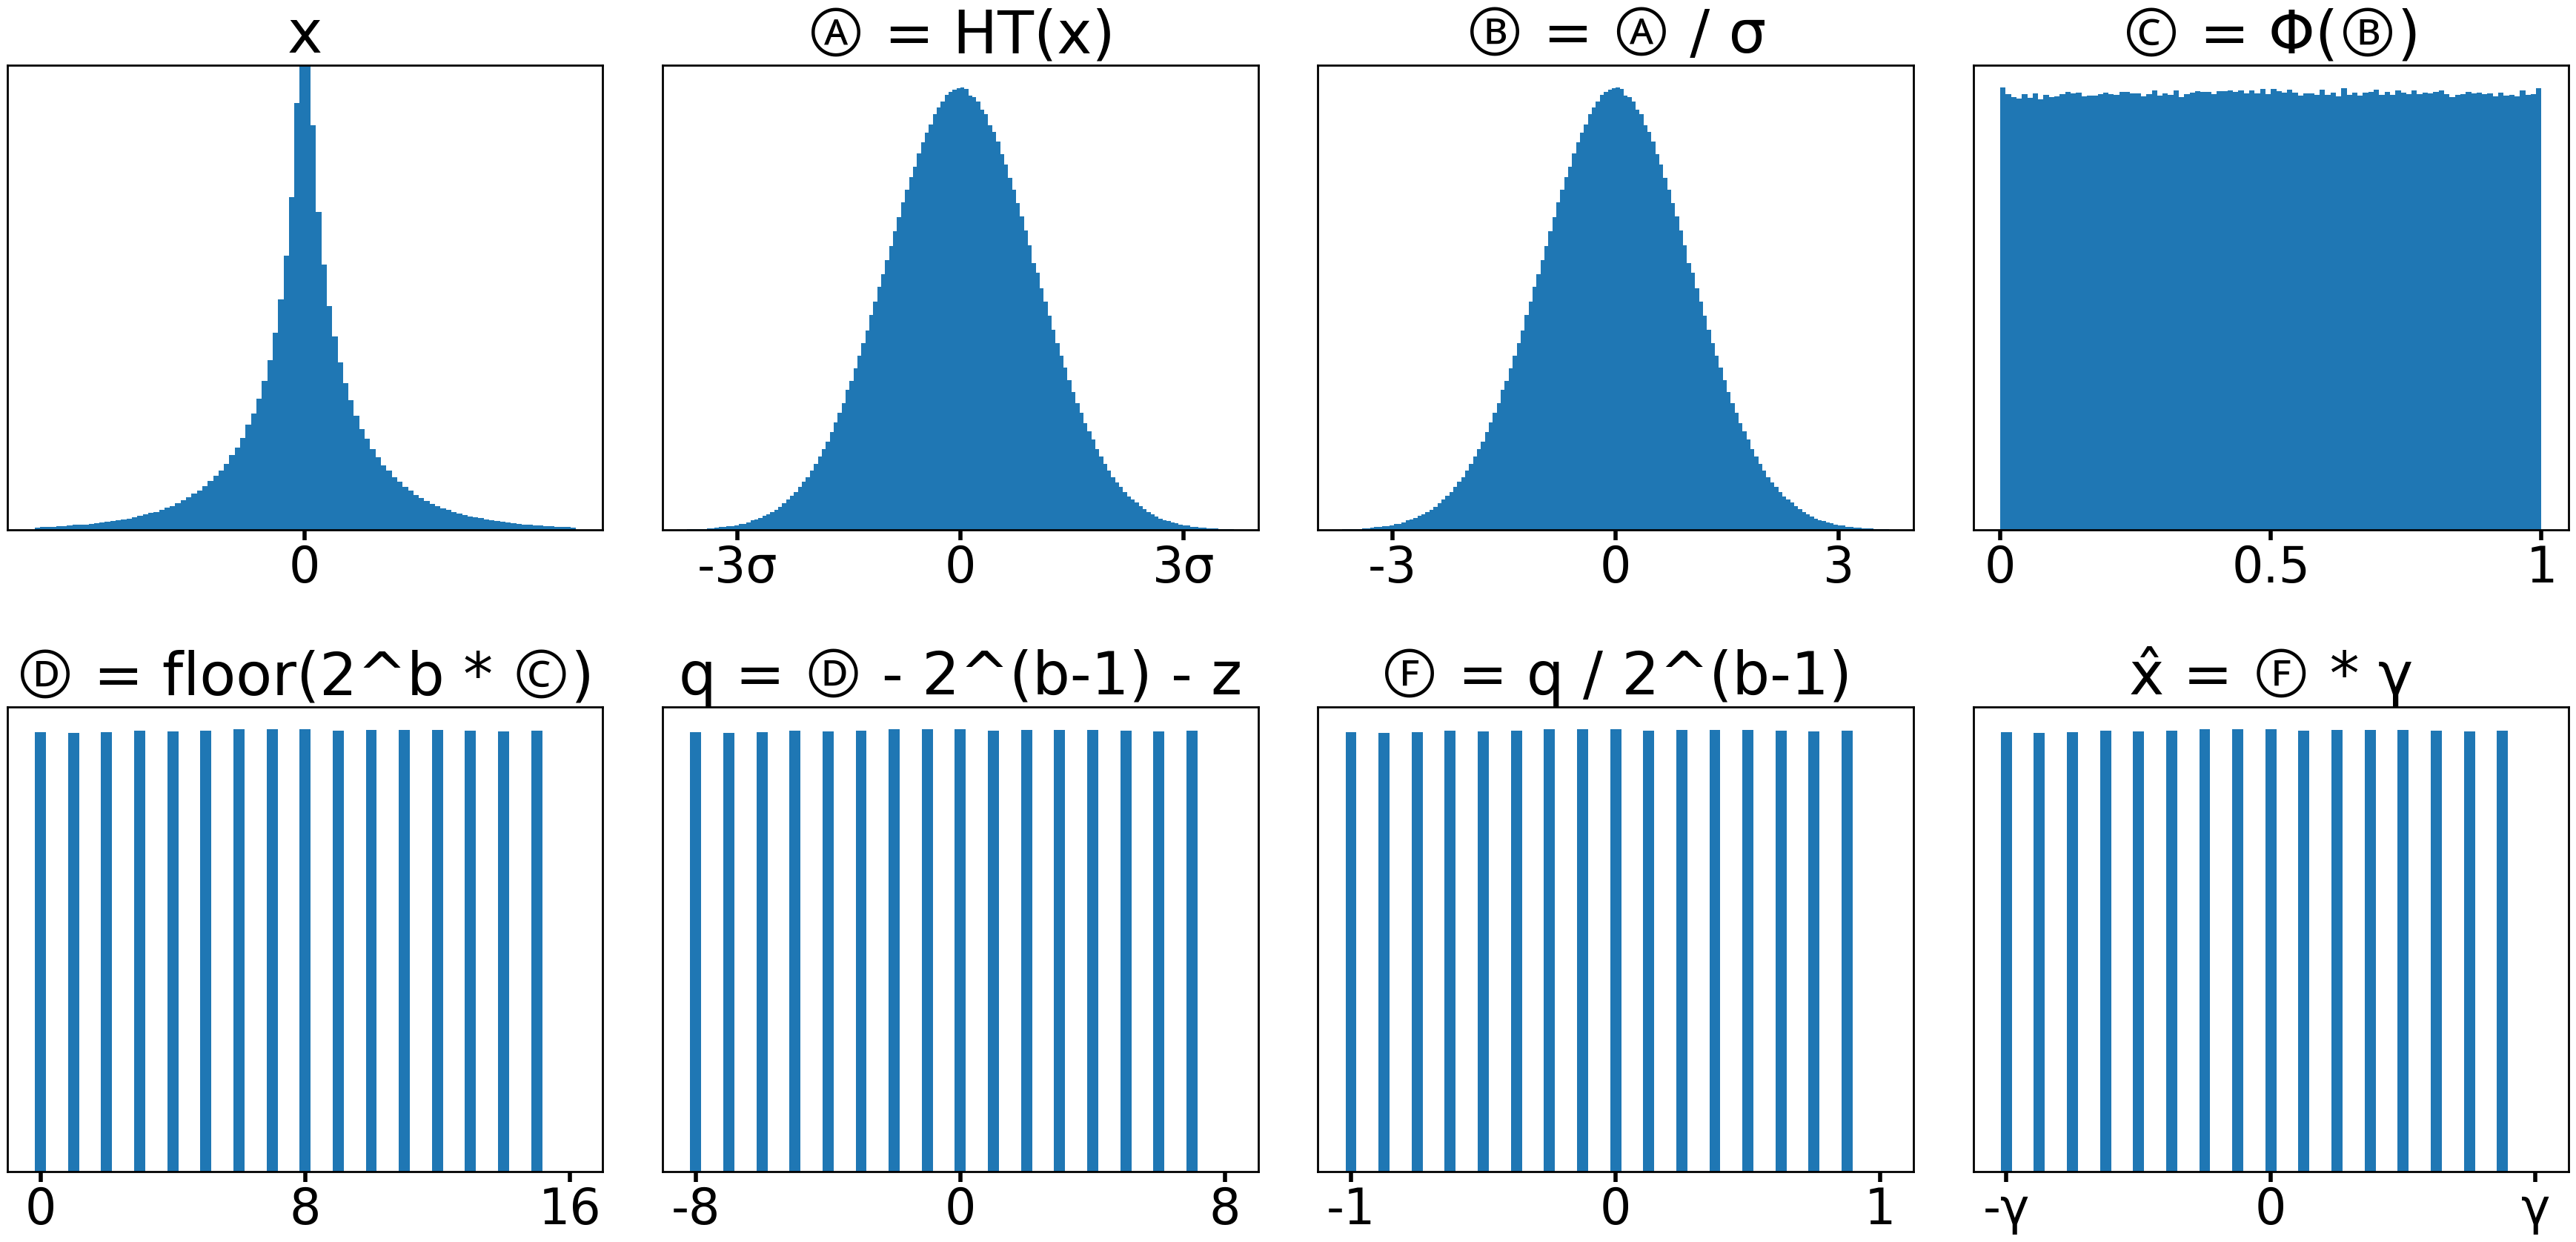

In [9]:
import torch
import matplotlib.pyplot as plt
from fast_hadamard_transform import hadamard_transform

plt.rcParams["font.size"] = 48
import matplotlib as mpl
plt.rcParams["xtick.major.width"] = 4
plt.rcParams["xtick.major.size"] = 10

mpl.rcParams["font.family"] = ["DejaVu Sans", "Noto Sans Symbols"]
mpl.rcParams["axes.unicode_minus"] = True
mpl.rcParams['axes.linewidth'] = 2

fig, axs = plt.subplots(2, 4, figsize=(36, 18))

LOGN = 11
N = 1 << LOGN

x = torch.randn((N, N))

w1 = torch.randn((N, N))
w2 = torch.randn((N, N))

y = torch.nn.functional.silu(x @ w1) * (x @ w2)

# yrange = torch.quantile(y, torch.Tensor([0.001, 0.999])).tolist()
sorted = y.flatten().sort()[0]
rat = 2e-3
yrange = [sorted[round(rat * sorted.numel())].item(), sorted[round((1-rat) * sorted.numel())].item()]
axs[0, 0].set_title("x")
axs[0, 0].hist(y.flatten(), bins=100, density=True, range=yrange)
axs[0, 0].set_ylim(0, 2e-4)
axs[0, 0].set_xticks([0], ["0"])
axs[0, 0].set_yticks([], [])

aux_matrix = hadamard_transform(
    torch.eye(N, dtype=torch.float32, device="cuda"), scale=2 ** (-LOGN / 2)
)
matrix = torch.block_diag(
    *[aux_matrix.to(y.device)] * (x.shape[-1] // N),
)
y = y @ matrix
std = y.std().item()
axs[0, 1].set_title("Ⓐ = HT(x)")
axs[0, 1].hist(y.flatten(), bins=200, density=True)
axs[0, 1].set_xticks([-3 * std, 0, 3 * std], ["-3σ", "0", "3σ"])
axs[0, 1].set_yticks([], [])
axs[0, 1].set_xlim(-4 * std, 4 * std)

y = y / y.square().mean().sqrt()
axs[0, 2].set_title("Ⓑ = Ⓐ / σ")
axs[0, 2].hist(y.flatten(), bins=200, density=True)
axs[0, 2].set_xticks([-3, 0, 3], ["-3", "0", "3"])
axs[0, 2].set_yticks([], [])
axs[0, 2].set_xlim(-4, 4)

y = torch.distributions.Normal(0, 1).cdf(y)
axs[0, 3].set_title("Ⓒ = Φ(Ⓑ)")
axs[0, 3].hist(y.flatten(), bins=100, density=True)
axs[0, 3].set_xticks([0, 0.5, 1], ["0", "0.5", "1"])
axs[0, 3].set_yticks([], [])

pretty = True
bar_width = 1/3

y = torch.floor(16 * y)
axs[1, 0].set_title("Ⓓ = floor(2^b * Ⓒ)")
if pretty:
    categories = []
    values = []
    for i in range(16):
        categories.append(str(i))
        values.append(torch.sum(y.int() == i).item())
    axs[1, 0].bar(categories, values, width=bar_width)
    axs[1, 0].set_xticks([0, 8, 16], ["0", "8", "16"])
    axs[1, 0].set_xlim(-1, 17)
else:
    axs[1, 0].hist(y.flatten(), bins=46, range=(0 - 1 / 6, 15 + 1 / 6))
    axs[1, 0].set_xticks([0, 8, 16], ["0", "8", "16"])
    axs[1, 0].set_xlim(-1, 17)
axs[1, 0].set_yticks([], [])

y = y - 8
axs[1, 1].set_title("q = Ⓓ - 2^(b-1) - z")
if pretty:
    axs[1, 1].bar(categories, values, width=bar_width)
    axs[1, 1].set_xticks([0, 8, 16], ["-8", "0", "8"])
    axs[1, 1].set_xlim(-1, 17)
else:
    axs[1, 1].hist(y.flatten(), bins=46, range=(-8 - 1 / 6, 7 + 1 / 6))
    axs[1, 1].set_xticks([-8, 0, 8], ["-8", "0","8"])
    axs[1, 1].set_xlim(-9, 9)
axs[1, 1].set_yticks([], [])

y = y / 8
axs[1, 2].set_title("Ⓕ = q / 2^(b-1)")
if pretty:
    axs[1, 2].bar(categories, values, width=bar_width)
    axs[1, 2].set_xticks([0, 8, 16], ["-1", "0",  "1"])
    axs[1, 2].set_xlim(-1, 17)
else:
    axs[1, 2].hist(y.flatten(), bins=46, range=(-1 - 1 / 48, 7 / 8  + 1 / 48))
    axs[1, 2].set_xticks([-1, 0, 1], ["-1", "0", "1"])
    axs[1, 2].set_xlim(-1 - 1 / 8, 1 + 1 / 8)
axs[1, 2].set_yticks([], [])

gamma = 3
y = y * gamma
axs[1, 3].set_title("x̂ = Ⓕ * γ")
if pretty:
    axs[1, 3].bar(categories, values, width=bar_width)
    axs[1, 3].set_xticks([0, 8, 16], ["-γ", "0", "γ"])
    axs[1, 3].set_xlim(-1, 17)
else:
    axs[1, 3].hist(y.flatten(), bins=46, range=((-1 - 1 / 48) * gamma, (7 / 8  + 1 / 48) * gamma))
    axs[1, 3].set_xticks([-gamma, 0, gamma], ["-γ", "0", "γ"])
    axs[1, 3].set_xlim((-1 - 1 / 8) * gamma, (1 + 1 / 8) * gamma)
axs[1, 3].set_yticks([], [])

plt.tight_layout()

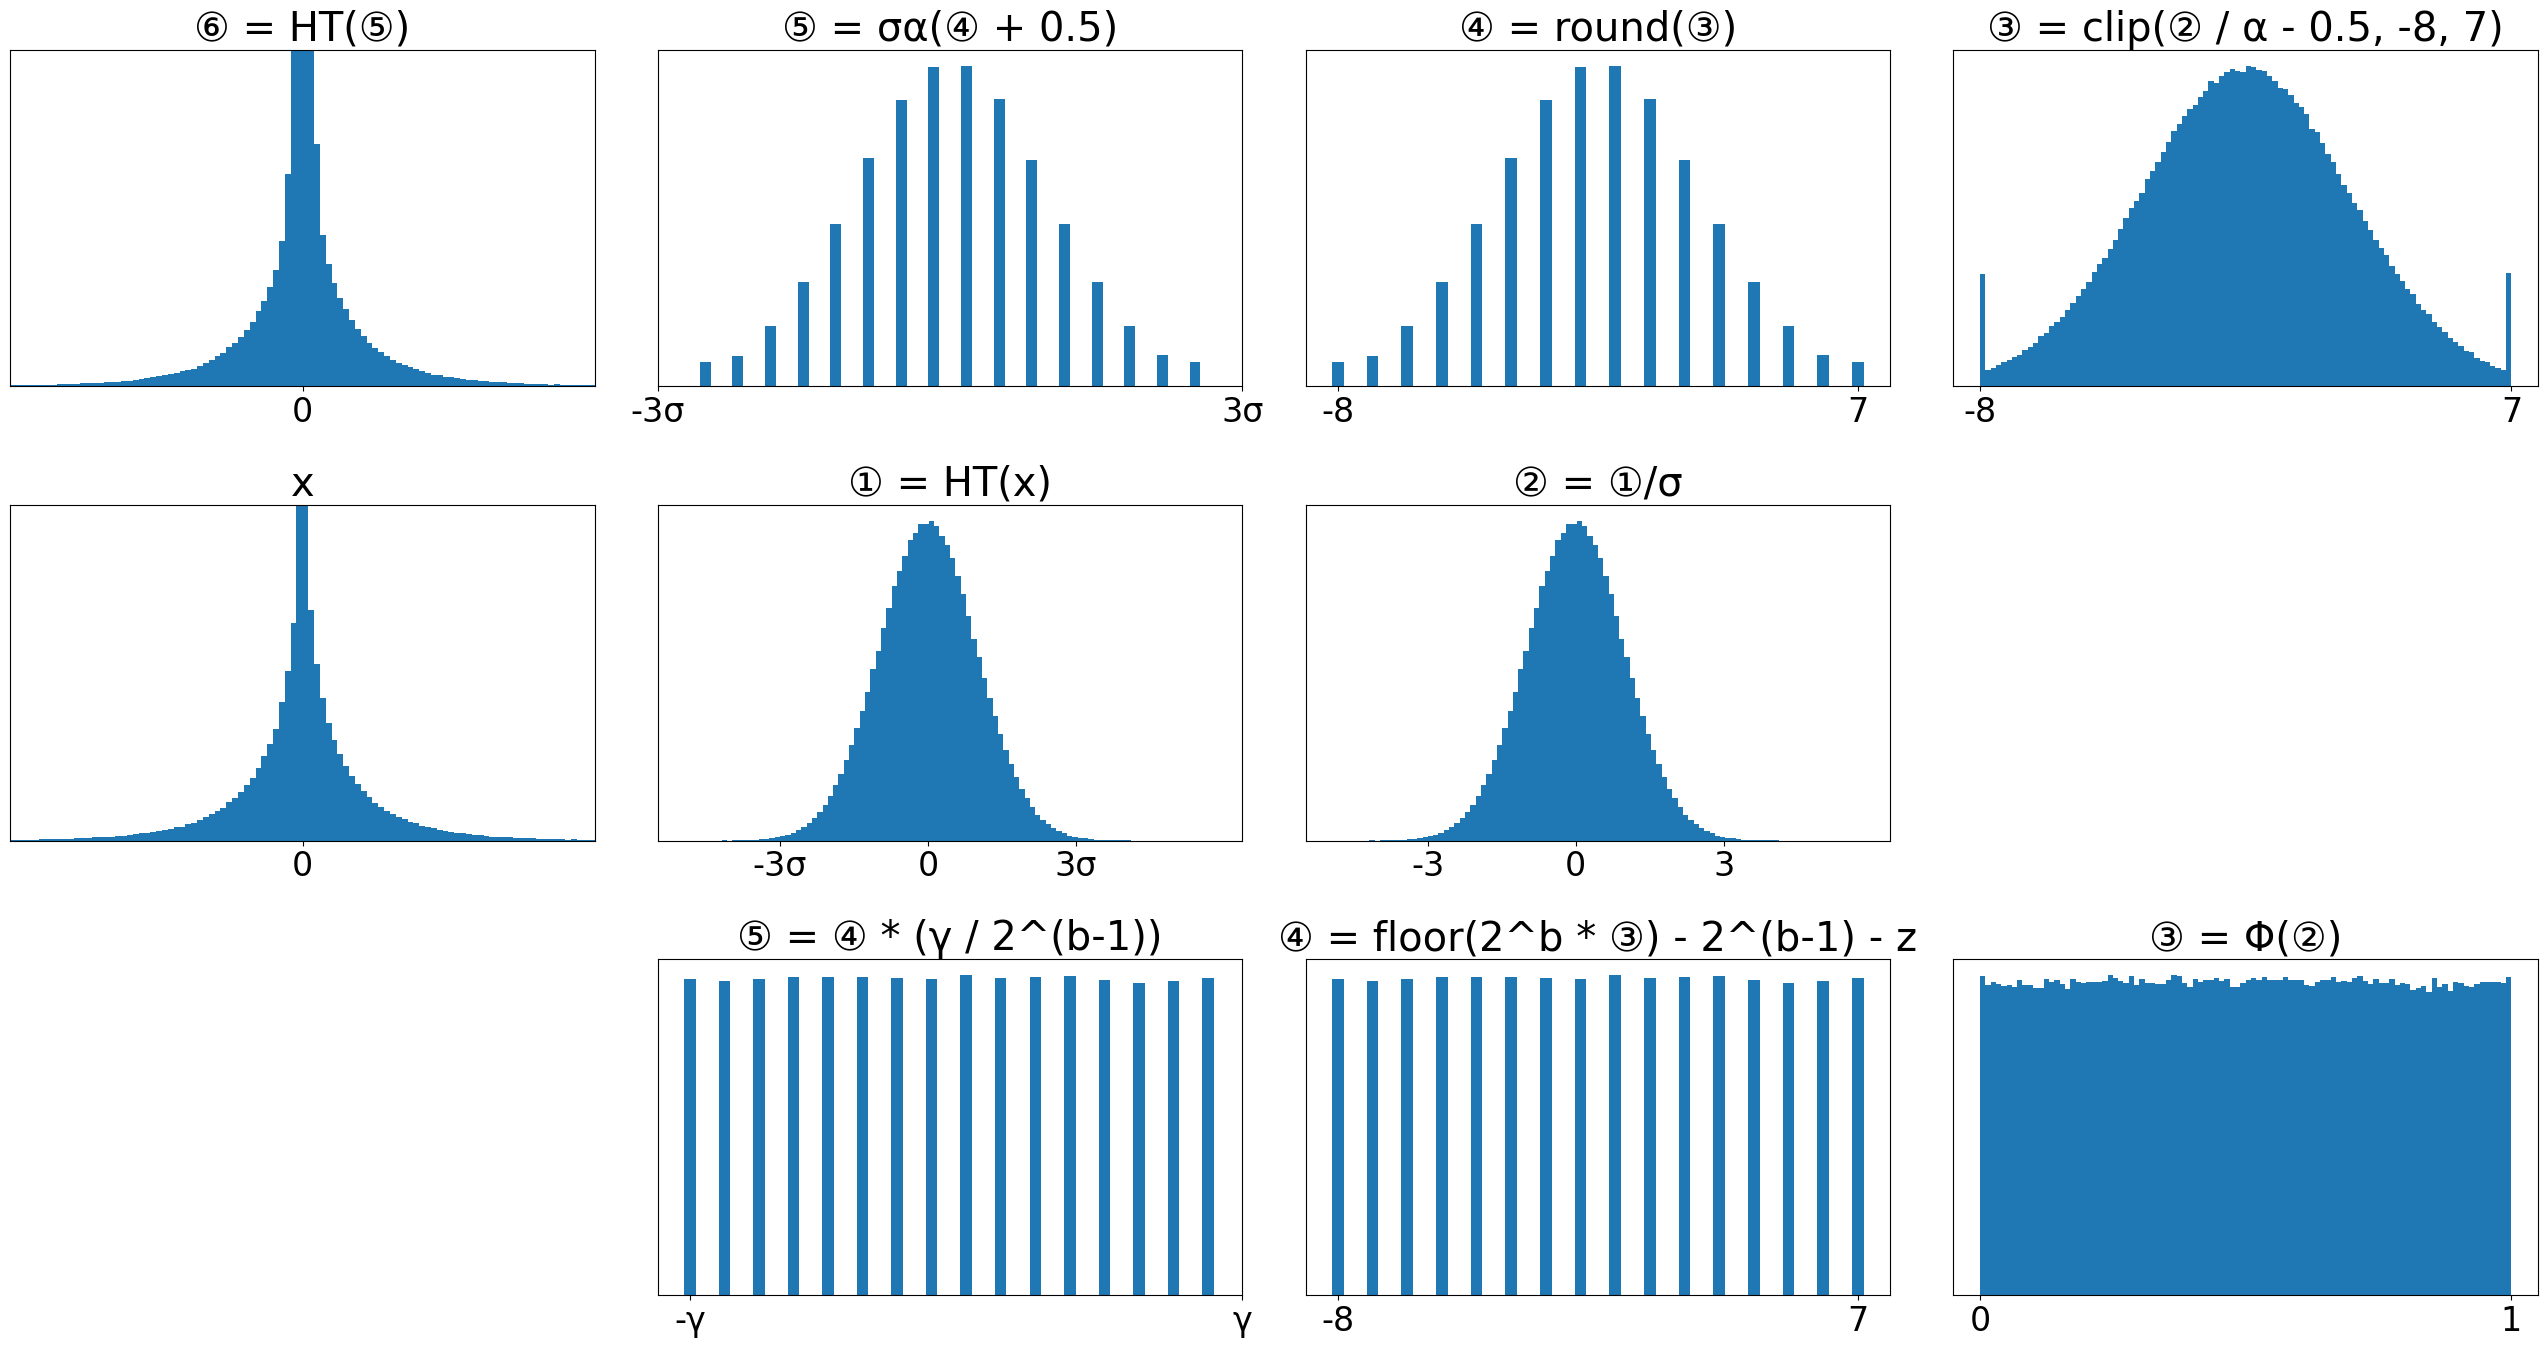

In [4]:
import torch
import matplotlib.pyplot as plt
from fast_hadamard_transform import hadamard_transform

plt.rcParams["font.size"] = 24

fig, axs = plt.subplots(3, 4, figsize=(26, 14))

x = torch.randn((1024, 1024))

w1 = torch.randn((1024, 1024))
w2 = torch.randn((1024, 1024))

y = torch.nn.functional.silu(x @ w1) * (x @ w2)

yrange = torch.quantile(y, torch.Tensor([0.001, 0.999])).tolist()
axs[1, 0].set_title("x")
axs[1, 0].hist(y.flatten(), bins=100, density=True, range=yrange)
axs[1, 0].set_ylim(0, 0.0005)
axs[1, 0].set_xticks([0], ["0"])
axs[1, 0].set_yticks([], [])
axs[1, 0].set_xlim(yrange[0], yrange[1])

LOGN = 10
N = 1 << LOGN
aux_matrix = hadamard_transform(
    torch.eye(N, dtype=torch.float32, device="cuda"), scale=2 ** (-LOGN / 2)
)
matrix = torch.block_diag(
    *[aux_matrix.to(y.device)] * (x.shape[-1] // N),
)
y = y @ matrix
std = y.std().item()
axs[1, 1].set_title("① = HT(x)")
axs[1, 1].hist(y.flatten(), bins=100, density=True)
axs[1, 1].set_xticks([-3 * std, 0, 3 * std], ["-3σ", "0", "3σ"])
axs[1, 1].set_yticks([], [])

rms = y.square().mean().sqrt().item()
y = y / rms
axs[1, 2].set_title("② = ①/σ")
axs[1, 2].hist(y.flatten(), bins=100, density=True)
axs[1, 2].set_xticks([-3, 0, 3], ["-3", "0", "3"])
axs[1, 2].set_yticks([], [])


OPTIMAL_GAUSSIAN_SCALES = {
    1: 0.7978845587140913,
    1.585: 1.2240089519030855,
    2: 1.4935346200015913,
    3: 2.051068354131873,
    4: 2.513930578568423,
    5: 2.9160938834961225,
    6: 3.276597282593217,
    7: 3.6010497188221655,
    8: 3.884938678807525,
}

scale = OPTIMAL_GAUSSIAN_SCALES[4]
alpha = (2 * scale / 15)
y1 = torch.clip(y / alpha - 0.5, -8, 7)
axs[0, 3].set_title("③ = clip(② / α - 0.5, -8, 7)")
axs[0, 3].hist(y1.flatten(), bins=100, density=True)
axs[0, 3].set_xticks([-8, 7], ["-8", "7"])
axs[0, 3].set_yticks([], [])

y1 = torch.round(y1)
axs[0, 2].set_title("④ = round(③)")
axs[0, 2].hist(y1.flatten(), bins=46, range=(-8 - 1 / 6, 7 + 1 / 6))
axs[0, 2].set_xticks([-8, 7], ["-8", "7"])
axs[0, 2].set_yticks([], [])

y1 = (y1 + 0.5) * alpha * rms
axs[0, 1].set_title("⑤ = σα(④ + 0.5)")
axs[0, 1].hist(y1.flatten(), bins=46, range=(((-8 - 1 / 6) + 0.5) * alpha * rms, ((7 + 1 / 6) + 0.5) * alpha * rms))
axs[0, 1].set_xticks([-3 * rms, 3 * rms], ["-3σ", "3σ"])
axs[0, 1].set_yticks([], [])

y1 = y1 @ matrix
axs[0, 0].hist(y1.flatten(), bins=100, density=True, range=yrange)
axs[0, 0].set_title("⑥ = HT(⑤)")
axs[0, 0].set_xticks([0], ["0"])
axs[0, 0].set_yticks([], [])
axs[0, 0].set_xlim(yrange[0], yrange[1])
axs[0, 0].set_ylim(0, 0.0005)


y2 = torch.distributions.Normal(0, 1).cdf(y)
axs[2, 3].set_title("③ = Φ(②)")
axs[2, 3].hist(y2.flatten(), bins=100, density=True)
axs[2, 3].set_xticks([0, 1], ["0", "1"])
axs[2, 3].set_yticks([], [])

y2 = torch.floor(16 * y2) - 8
axs[2, 2].set_title("④ = floor(2^b * ③) - 2^(b-1) - z")
axs[2, 2].hist(y2.flatten(), bins=46, range=(-8 - 1 / 6, 7 + 1 / 6))
axs[2, 2].set_xticks([-8, 7], ["-8", "7"])
axs[2, 2].set_yticks([], [])

gamma = 1.68 * rms
y2 = y2 / 8 * gamma
axs[2, 1].set_title("⑤ = ④ * (γ / 2^(b-1))")
axs[2, 1].hist(y2.flatten(), bins=46, range=((-8 - 1 / 6) / 8 * gamma, (7 + 1 / 6) / 8 * gamma))
axs[2, 1].set_xticks([-gamma, gamma], ["-γ", "γ"])
axs[2, 1].set_yticks([], [])

axs[2, 0].axis('off') 
axs[1, 3].axis('off') 
plt.tight_layout()

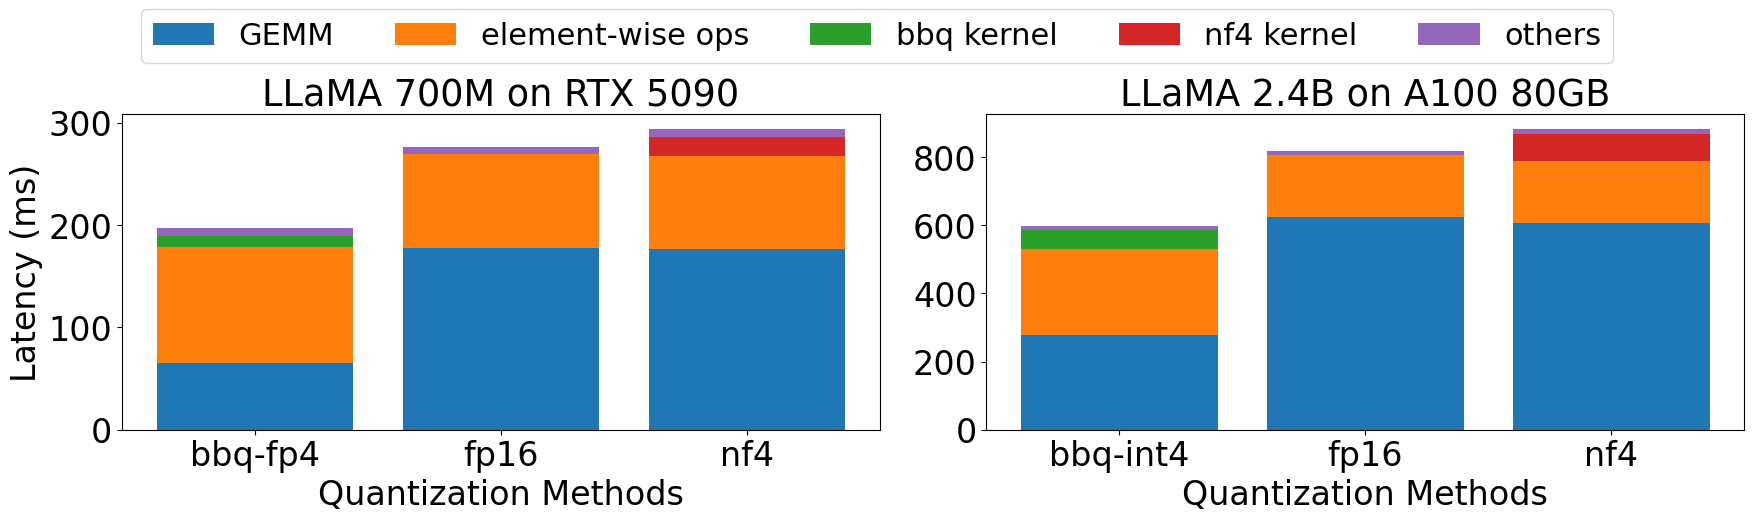

In [40]:
import numpy as np
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(18, 5))
plt.rcParams["font.size"] = "22"

gemm = np.array([276_911, 624_131, 606_698]) / 1000
element = np.array([251_764, 182_277, 181_959]) / 1000
bbq = np.array([55_979, 0, 0]) / 1000
nf4 = np.array([0, 0, 79_972]) / 1000
total = np.array([596_929, 818_780, 881_111]) / 1000

methods = ["bbq-int4", "fp16", "nf4"]
x = np.arange(len(methods))
axs[1].bar(x, gemm, label="GEMM")
axs[1].bar(x, element, bottom=gemm, label="element-wise ops")
axs[1].bar(x, bbq, bottom=gemm + element, label="bbq kernel")
axs[1].bar(x, nf4, bottom=gemm + element + bbq, label="nf4 kernel")
axs[1].bar(x, total - gemm - element - bbq - nf4, bottom=gemm + element + bbq + nf4, label="others")

axs[1].set_xticks(x, methods)
axs[1].set_xlabel("Quantization Methods")
axs[1].set_title("LLaMA 2.4B on A100 80GB")

gemm = np.array([65_163, 177_199, 176_717]) / 1000
element = np.array([113_247, 91_915, 90840]) / 1000
bbq = np.array([11_264, 0, 0]) / 1000
nf4 = np.array([0, 0, 18_383]) / 1000
total = np.array([197_013, 276_505, 293_355]) / 1000

methods = ["bbq-fp4", "fp16", "nf4"]
x = np.arange(len(methods))
axs[0].bar(x, gemm)
axs[0].bar(x, element, bottom=gemm)
axs[0].bar(x, bbq, bottom=gemm + element)
axs[0].bar(x, nf4, bottom=gemm + element + bbq)
axs[0].bar(x, total - gemm - element - bbq - nf4, bottom=gemm + element + bbq + nf4)

axs[0].set_xticks(x, methods)
axs[0].set_ylabel("Latency (ms)")
axs[0].set_xlabel("Quantization Methods")
axs[0].set_title("LLaMA 700M on RTX 5090")

fig.legend(loc="upper center", ncols=5, bbox_to_anchor=(0.5, 1.1))
plt.tight_layout()

In [19]:
from PIL import Image

# Open the image
img = Image.open('fig3.png')
size = img.size
split0 = 4
split1 = 1
size0 = size[0] // split0
size1 = size[1] // split1
for i in range(0, split0):
    for j in range(0, split1):
        sizea = (i * size0, j * size1, (i+1) * size0, (j+1) * size1)
        img.crop(sizea).save(f"fig3-{i}-{j}.png")

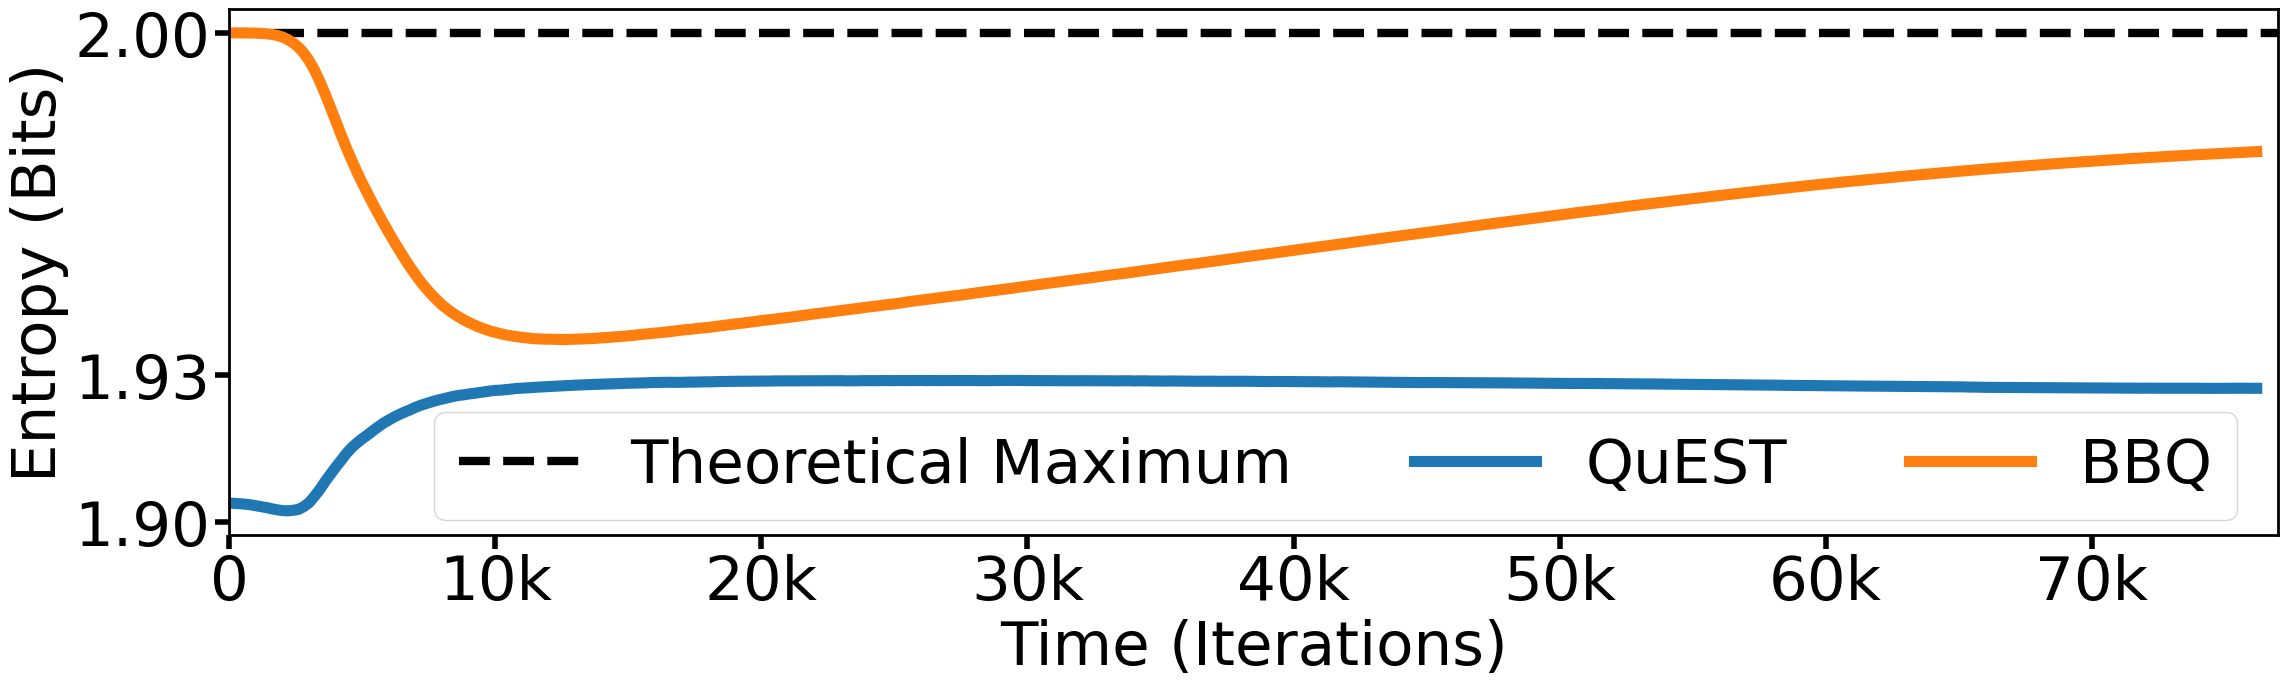

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.size"] = 44
plt.rcParams["xtick.major.width"] = 4
plt.rcParams["xtick.major.size"] = 10
plt.rcParams["ytick.major.width"] = 4
plt.rcParams["ytick.major.size"] = 10
plt.rcParams['axes.linewidth'] = 2

data = pd.read_csv("ent.csv")

plt.figure(figsize=(24, 8))
plt.axhline(y=2, xmin=0, xmax=80000, label="Theoretical Maximum", color="black", linewidth=6, linestyle="--")
plt.plot(data["iter"], data["QuEST"], label="QuEST", linewidth=8)
plt.plot(data["iter"], data["BBQ"], label="BBQ", linewidth=8)
plt.xticks([i * 10000 for i in range(8)], [f"{i*10}k" if i != 0 else "0" for i in range(8)])
plt.ylabel("Entropy (Bits)")
plt.xlabel("Time (Iterations)")
plt.xlim(0, 77000)
plt.yticks([1.9, 1.93, 2], ["1.90", "1.93", "2.00"])
plt.tight_layout()
plt.legend(loc="lower center", ncol=3, bbox_to_anchor=(0.54, -0.03))

/tmp/ipykernel_696566/595891823.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  cp = torch.load(file, map_location="cpu")


Text(0, 0.5, 'Frequency')

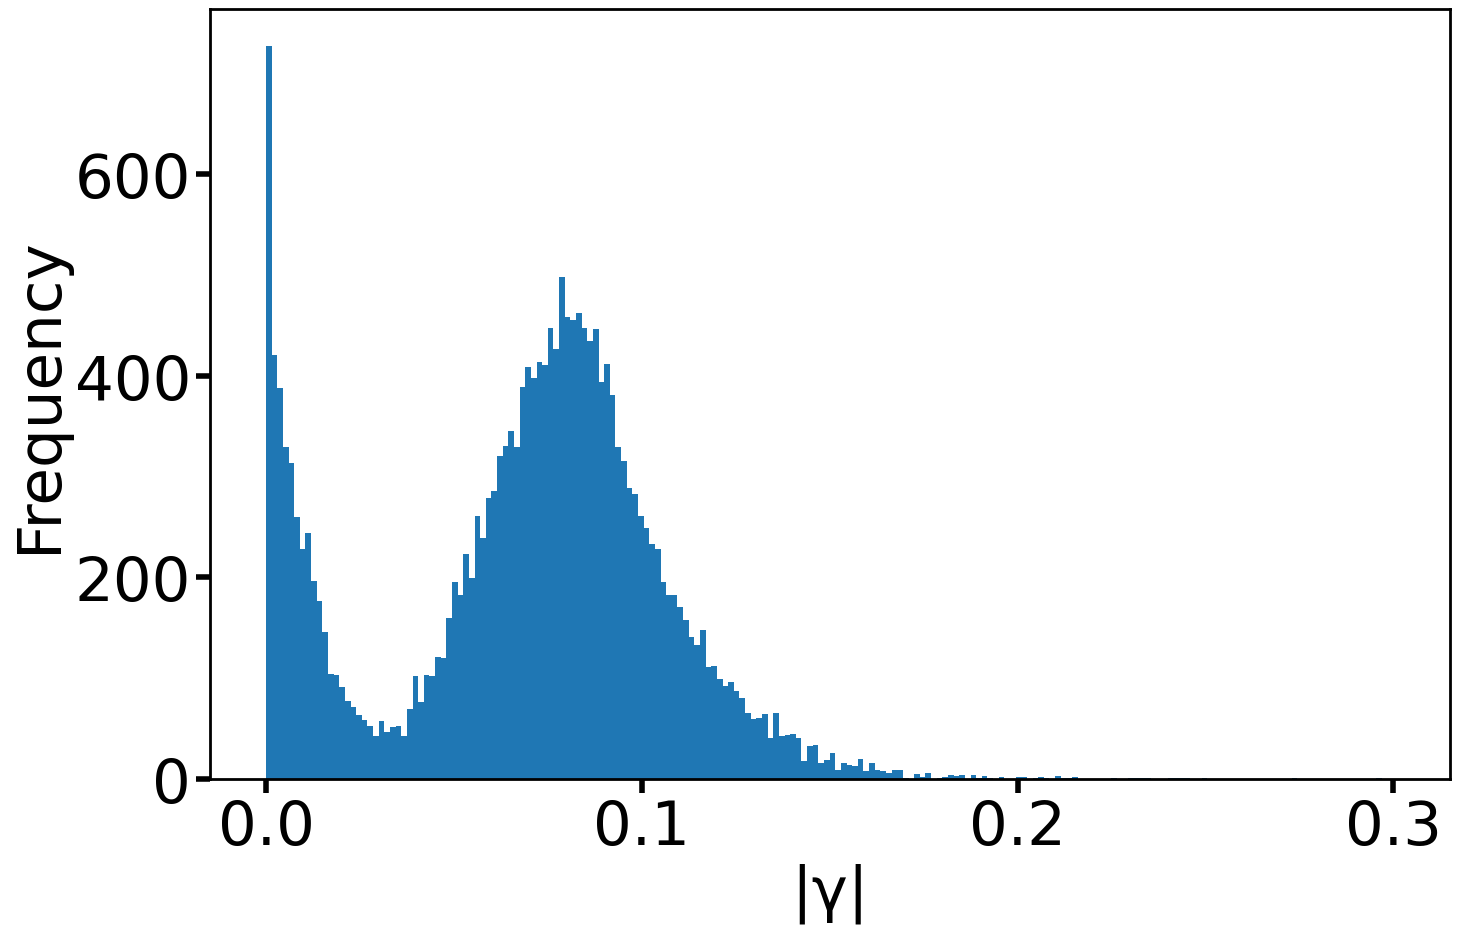

In [1]:
import torch
import matplotlib.pyplot as plt

plt.rcParams["font.size"] = 44
plt.rcParams["xtick.major.width"] = 4
plt.rcParams["xtick.major.size"] = 10
plt.rcParams["ytick.major.width"] = 4
plt.rcParams["ytick.major.size"] = 10
plt.rcParams['axes.linewidth'] = 2
plt.figure(figsize=(16, 10))
file = "vision/exps/final2QWBBQNaiveHDChanprecision2zeropoint0.5QABBQNaiveHDprecision2zeropoint0.5QKSVNoQuantizerMdeittinypatch16224DIMNET100E3005B64LR0.00051e05OadamwWD0.05ScosineCGNoneWS1EFalseDTfloat32C0PT0SE0S0FIXSCHED/checkpoint__.pth"
cp = torch.load(file, map_location="cpu")
gammas = []
for name, param in cp["model"].items():
    if name.endswith(".sx"):
        gammas.append(param.abs().flatten())
gammas = torch.cat(gammas)
plt.hist(gammas, bins=200, range=(-0.0, 0.3))
plt.xlabel("|γ|")
plt.ylabel("Frequency")

Text(0, 0.5, 'Frequency')

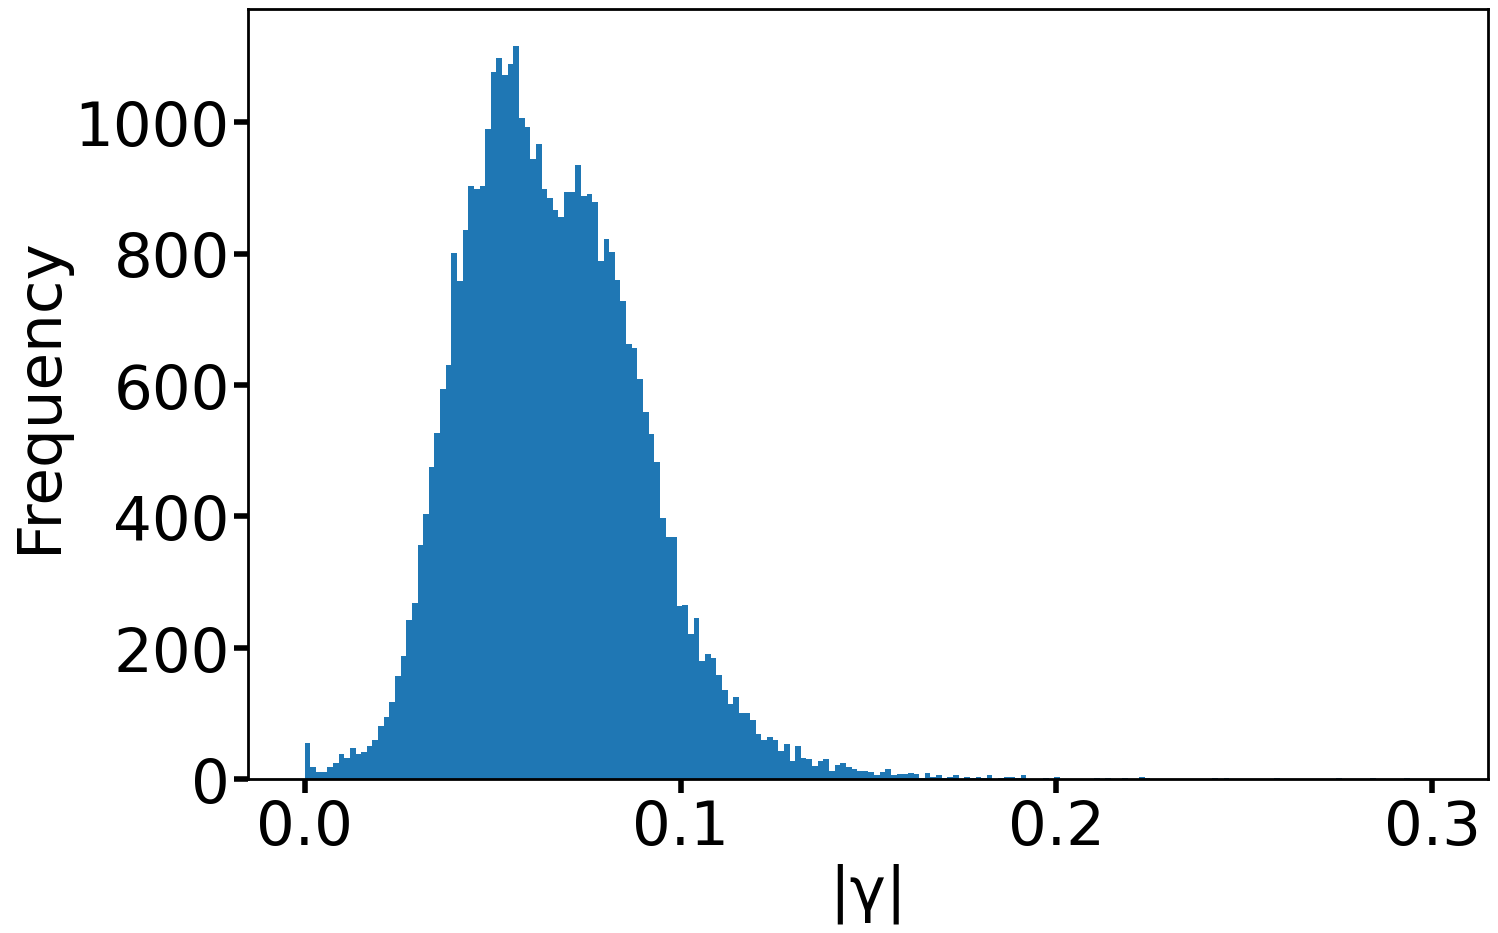

In [3]:
import torch
import matplotlib.pyplot as plt


plt.rcParams["font.size"] = 44
plt.rcParams["xtick.major.width"] = 4
plt.rcParams["xtick.major.size"] = 10
plt.rcParams["ytick.major.width"] = 4
plt.rcParams["ytick.major.size"] = 10
plt.rcParams['axes.linewidth'] = 2
plt.figure(figsize=(16, 10))
file = "exps/LLaMA-30M-BBQV5HDChan@2@-0.5:BBQV5HD@2@-0.5-c4_c4_llama_nlayers6_nhead5_lr0.0012_sched_cos_warmup1144_decay_linear_0.1_iter11444_bs64x8_ws1_seed0_data_seed1337/ckpts/latest/main.pt"
cp = torch.load(file, map_location="cpu")
gammas = []
for name, param in cp["model"].items():
    if name.endswith(".sx"):
        gammas.append(param.abs().flatten())
gammas = torch.cat(gammas)
plt.hist(gammas, bins=200, range=(-0.0, 0.3))
plt.xlabel("|γ|")
plt.ylabel("Frequency")